# How KMeans work


1. Choose K value
2. Place K random centroids(These are temporary centroid points)
3. Assign points to nearest centroids
4. Recalculate the centroid mean value
5. Repeat step 3 and 4 until center points stop moving
-- Moves centroid to another location in same group until it get the least mean value then centroid value will be fixed<br>

1. Scaling is mandatory for KMeans
2. It is outliers sensitive<br>
-- If a column contains 1 digit number and another column have 3 digit number then it requires scaling else if the two columns have the 2 digit number no need of scaling<br>
3. Inertia finds the distance betwn each value to centroid and square to it
4. Inertia give quality of cluster(points are near to centroid or not/tightly clustered or not)<br>
5. K value increases, the inertia decreases.Because<br>
-- Number of clusters increases<br>
-- Data points become closer to centroids<br>
-- Distance reduces<br>
-- Therefore inertia decreases<br>

# Inertia
-- Inertia is the total distance of all points from their repective cluster centers.
-- It measures how compact the clusters are

# Real time projects on KMeans
1. Customer segmentation for Ecommerce Website
2. Movie recommendation cluster
3. Smart phone usage segmentation
4. Patient risk segmentation
5. Fraud detection
6. Student Performance(toppers,avg students,risk studets)


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df=pd.read_csv("student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [69]:
df.shape

(649, 33)

In [70]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [71]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

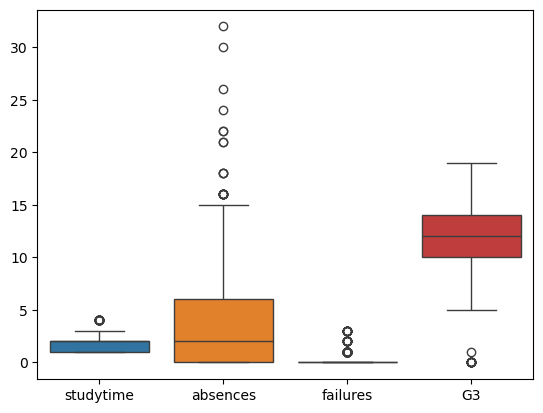

In [72]:
sns.boxplot(df[["studytime","absences","failures","G3"]])
plt.show()

In [82]:
cols=['studytime', 'failures', 'absences', 'G3']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]








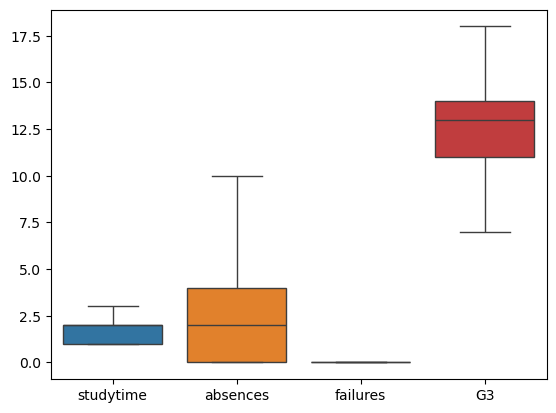

In [83]:
sns.boxplot(df[["studytime","absences","failures","G3"]])
plt.show()

In [84]:
x=df[['studytime', 'failures', 'absences', 'G3']]

In [85]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [86]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [99]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

kmeans.fit(x_scaled)

c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [100]:
df['Cluster'] = kmeans.labels_

In [101]:
df["Cluster"].nunique

<bound method IndexOpsMixin.nunique of 0      1
1      1
2      1
3      0
4      0
      ..
643    1
645    0
646    1
647    1
648    1
Name: Cluster, Length: 478, dtype: int32>

In [102]:
df['Cluster'] = df['Cluster'].replace({
    0: 'Average Students',
    1: 'High Performers',
    2: 'Low Performers'
})

df[['Cluster']].head()

,Cluster
0,High Performers
1,High Performers
2,High Performers
3,Average Students
4,Average Students


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17840\2886856174.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


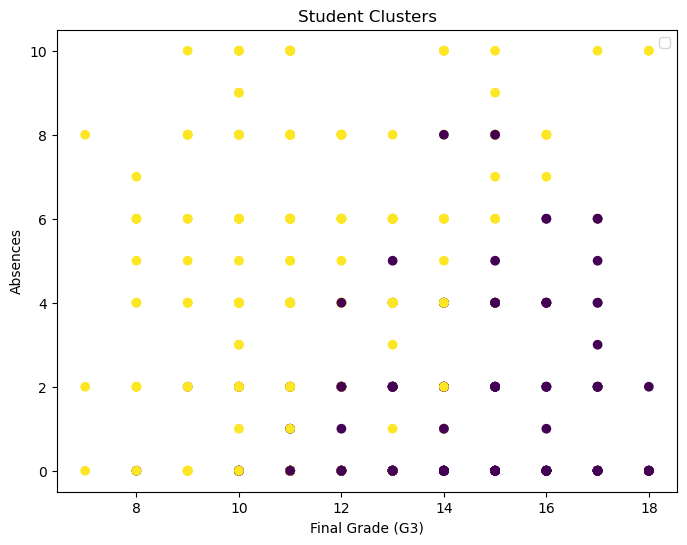

In [103]:
plt.figure(figsize=(8,6))
plt.scatter(df['G3'],df['absences'],c=kmeans.labels_,)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Absences")
plt.title("Student Clusters")
plt.legend()
plt.show()